In [1]:
%reset -f
import pandas as pd
# df_manuscript = pd.read_excel("/Users/lingyi/Documents/spatial/colocalization/MI_lists/dataset_in_manuscript.xlsx")

# df_filter_high_aCAF = df_manuscript
# selected_samples = ['CID4465_spatial', 'SN124_A938797_Rep2', 'HT232P1H2A2', 'GSM7498813_SS1945070_processed']
# df_filter_high_aCAF = df_filter_high_aCAF[df_filter_high_aCAF['SampleID'].isin(selected_samples)]
# df_filter_high_aCAF

In [2]:
import os
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import importlib
import sys
from pathlib import Path
sys.path.append("/Users/lingyi/Documents/spatial/colocalization/functions")

import tools
importlib.reload(tools)
outs_path = "/Users/lingyi/Documents/spatial/datasets/HD/visium-hd-cytassist-gene-expression-libraries-human-breast-cancer-ff-ultima-4" 
bin_size = "segmented_outputs"   
proc = tools.spatialTool()
adata = proc.visiumHDreader(outs_path, bin_size)

/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/__init__.py:44: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  return module_get_attr_red

Filtered cells without cluster assignments: 0 removed, 38993 retained (out of 38993 total)


In [3]:
# ============= CONFIGURATION SECTION =============
# Cell population: Always use STROMAL cells (identified by LUM expression)
STROMAL_MARKER = "LUM"  # Marker to identify stromal/fibroblast clusters
Z_THRESHOLD = 0.5  # Threshold for identifying high-expressing clusters
# ==================================================
def identify_clusters_by_expression(adata, genes, z_threshold=0.5):
    """
    Identify clusters highly expressing given gene(s) using z-score thresholding.
    If multiple genes provided, uses average expression.
    Returns clusters with expression > mean + z_threshold * std.
    """
    if isinstance(genes, str):
        genes = [genes]
    
    cluster_means = {}
    
    for cluster in adata.obs['clusters'].unique():
        mask = adata.obs['clusters'] == cluster
        
        # Calculate mean expression across all provided genes
        cluster_expr_values = []
        for gene in genes:
            if gene in adata.var_names:
                expr = adata[mask, gene].X
                if hasattr(expr, "toarray"):
                    expr = expr.toarray()
                expr = np.array(expr).flatten()
                cluster_expr_values.append(np.mean(expr))
        
        # Average across genes
        if len(cluster_expr_values) > 0:
            cluster_means[cluster] = np.mean(cluster_expr_values)
        else:
            cluster_means[cluster] = 0

    # Convert to array for stats
    means = np.array(list(cluster_means.values()))
    mean_all = np.mean(means)
    std_all = np.std(means)

    # Choose clusters above threshold
    high_clusters = [c for c, m in cluster_means.items() if m > (mean_all + z_threshold * std_all)]

    gene_str = ", ".join(genes)
    print(f"\n=== {gene_str} Expression Cluster Scan ===")
    print(f"Cluster Mean Expressions: {cluster_means}")
    print(f"Mean: {mean_all:.3f} | Std: {std_all:.3f} | Threshold: {mean_all + z_threshold*std_all:.3f}")
    print(f"High {gene_str} clusters: {high_clusters}")

    return high_clusters

def calculate_signature_score(adata, gene_list, score_name):
    """Calculate signature score as mean expression of genes in the list"""
    if isinstance(gene_list, str):
        gene_list = [gene_list]
    
    # Use scanpy's built-in subsetting to safely handle gene selection
    present_genes = [gene for gene in gene_list if gene in adata.var_names]
    
    if len(present_genes) == 0:
        raise ValueError(f"None of the genes in {gene_list} found in the dataset")
    
    # Use adata subsetting which handles duplicate gene names properly
    adata_subset = adata[:, present_genes]
    signature_expr = adata_subset.X
    
    if hasattr(signature_expr, 'toarray'):
        signature_expr = signature_expr.toarray()
    
    # Calculate mean across genes (axis=1 for mean across genes for each cell)
    signature_score = np.mean(signature_expr, axis=1)
    adata.obs[score_name] = signature_score
    
    return signature_score

def analyze_stromal_expression_by_tumor_proximity_annotation(adata, radius=200):
    """
    Analyze expression of specified genes in stromal cells based on distance to tumor.
    Returns expression scores in stromal cells near vs far from tumor, and their distances.
    """
    coords = adata.obsm['spatial_um']
    
    # Get tumor spot indices
    tumor_indices = np.where(adata.obs['annotation_tumor'])[0]
    tumor_coords = coords[tumor_indices]

    # For each spot, calculate distance to nearest tumor
    all_distances_to_tumor = []
    for i, coord in enumerate(coords):
        if len(tumor_coords) > 0:
            distances_to_tumors = np.sqrt(np.sum((tumor_coords - coord)**2, axis=1))
            min_distance = np.min(distances_to_tumors)
        else:
            min_distance = np.inf
        all_distances_to_tumor.append(min_distance)
    all_distances_to_tumor = np.array(all_distances_to_tumor)
    
    # Define masks - focus on stromal cells only
    stromal_mask = adata.obs['annotation_stromal'].values
    tumor_mask = adata.obs['annotation_tumor'].values
    other_cells_mask = ~(stromal_mask | tumor_mask)

    # Stromal cells near vs far from tumor
    stromal_near_tumor_mask = stromal_mask & (all_distances_to_tumor <= radius)
    stromal_far_tumor_mask = stromal_mask & (all_distances_to_tumor > radius)
    
    stromal_scores_near_tumor = adata.obs.loc[stromal_near_tumor_mask, 'expression_score'].values
    stromal_scores_far_tumor = adata.obs.loc[stromal_far_tumor_mask, 'expression_score'].values
    
    # compute for ALL OTHER (non-stromal, non-tumor) spots
    other_near_tumor_mask = other_cells_mask & (all_distances_to_tumor <= radius)
    other_far_tumor_mask = other_cells_mask & (all_distances_to_tumor > radius)

    other_scores_near_tumor = adata.obs.loc[other_near_tumor_mask, 'expression_score'].values
    other_scores_far_tumor = adata.obs.loc[other_far_tumor_mask, 'expression_score'].values
    
    # Get distances and stromal expression scores
    stromal_distances = all_distances_to_tumor[stromal_mask]
    stromal_scores = adata.obs.loc[stromal_mask, 'expression_score'].values
    
    return (stromal_scores_near_tumor, stromal_scores_far_tumor, 
            other_scores_near_tumor, other_scores_far_tumor, 
            stromal_distances, stromal_scores)



Processing 8 markers for Visium HD data...
Optimized: Load sample once, calculate all 8 markers

===== HD_colorectal_cancer =====
  Loading data...


/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Filtered cells without cluster assignments: 0 removed, 38993 retained (out of 38993 total)

=== LUM Expression Cluster Scan ===
Cluster Mean Expressions: {7: 1.1501873, 6: 0.9824605, 1: 1.9491675, 2: 1.1314055, 3: 0.54809916, 5: 1.3674458, 11: 3.1177418, 9: 1.9338824, 12: 0.9093803, 8: 0.23812483, 4: 2.3931973, 10: 0.35982448}
Mean: 1.340 | Std: 0.826 | Threshold: 1.753
High LUM clusters: [1, 11, 9, 4]

=== EPCAM Expression Cluster Scan ===
Cluster Mean Expressions: {7: 0.047438208, 6: 0.14196211, 1: 0.060338873, 2: 0.029576186, 3: 1.5408305, 5: 0.049297534, 11: 0.03105633, 9: 0.19780104, 12: 0.031842086, 8: 1.5312414, 4: 0.13193576, 10: 1.6392113}
Mean: 0.453 | Std: 0.648 | Threshold: 0.777
High EPCAM clusters: [3, 8, 10]
    Processing aCAF markers...
    Processing T cell marker...
    Processing Cytotoxic T cell marker...
    Processing Memory T cell marker...
    Processing Regulatory T cell marker...
    Processing B cell marker...
    Processing Macrophage marker...
    Processi

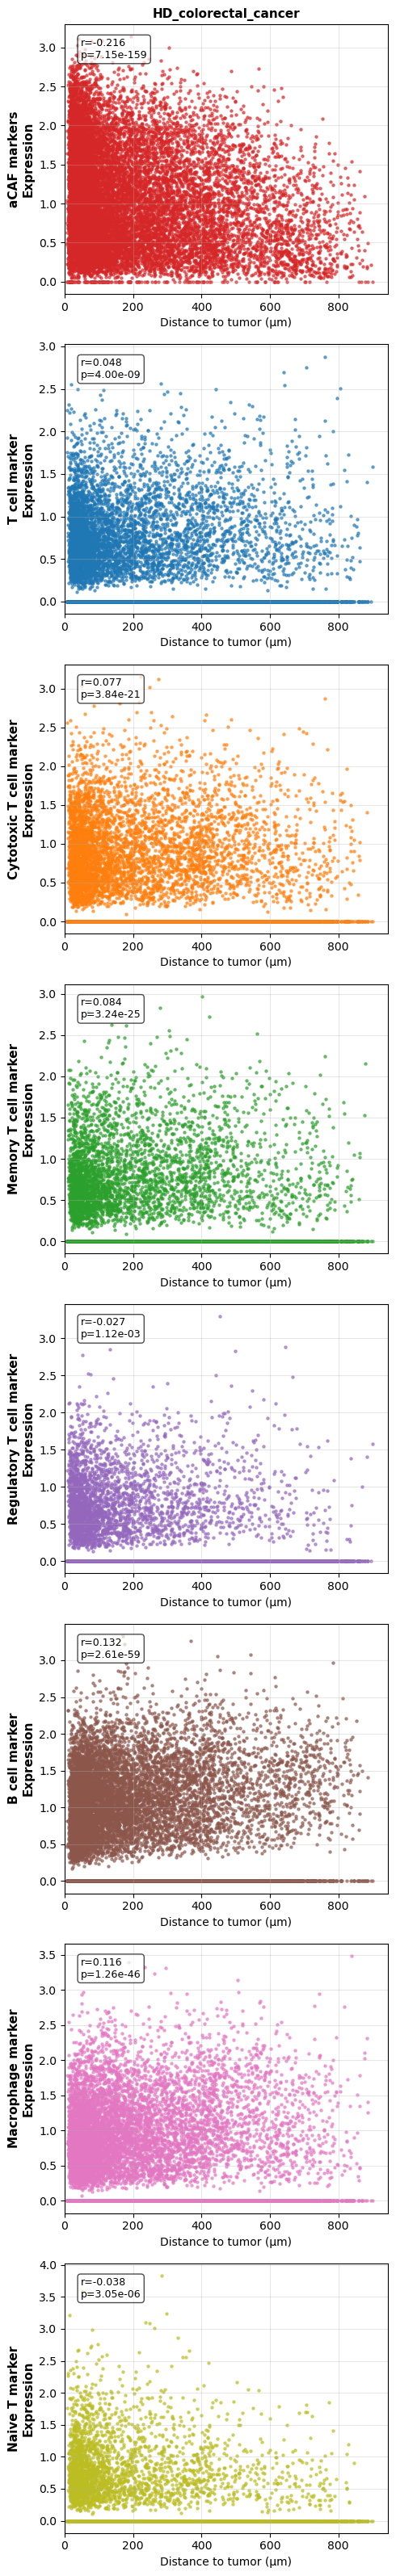

In [4]:
# ============= NEW: Multi-marker analysis configuration =============
# Define markers to analyze in order
MARKER_CONFIGS = [
    {
        'label': 'aCAF markers',
        'genes': ["COL11A1", "THBS2", "COL10A1", "COL5A2", "INHBA", "LRRC15", "COL5A1", "VCAN", "FAP", "COL1A1"],
        'color': "#d62728"  # brick red
    },
    {
        'label': 'T cell marker',
        'genes': ["CD3D"],
        'color': "#1f77b4"  
    },
    {
        'label': 'Cytotoxic T cell marker',
        'genes': ["CD8A"],
        'color': "#ff7f0e" 
    },
    {
        'label': 'Memory T cell marker',
        'genes': ["TCF7"],
        'color': "#2ca02c"  
    },
    {
        'label': 'Regulatory T cell marker',
        'genes': ["FOXP3"],
        'color': "#9467bd"  
    },
    {
        'label': 'B cell marker',
        'genes': ["CD79A"],
        'color': "#8c564b" 
    },
    {
        'label': 'Macrophage marker',
        'genes': ["CD163"],
        'color': "#e377c2" 
    },
    {
        'label': 'Naive T marker',
        'genes': ["CCR7"],
        'color': "#bcbd22" 
    }
]

def process_single_sample(dataset_name, sampleID, base_folder="/Volumes/T7/datasets", 
                         use_visium_hd=False, outs_path=None, bin_size=None):
    """
    Load a single sample once and process all markers for that sample.
    Returns a list of results, one for each marker.
    
    Parameters:
    -----------
    use_visium_hd : bool
        If True, use visiumHDreader with outs_path and bin_size
        If False, use standard dataprocess with base_folder structure
    outs_path : str
        Path for Visium HD data (only used if use_visium_hd=True)
    bin_size : str
        Bin size for Visium HD data (only used if use_visium_hd=True)
    """
    
    try:
        # Load and process data ONCE
        print(f"  Loading data...")
        proc = tools.spatialTool()
        
        if use_visium_hd and outs_path is not None:
            # Use Visium HD reader - clusters and spatial_um are now added automatically
            adata = proc.visiumHDreader(outs_path, bin_size)
        else:
            # Use standard data processing
            folder = f"{base_folder}/{dataset_name}/raw/{sampleID}"
            adata = proc.dataprocess(folder, skip_qc=False, verbose=False)
        
        # Identify STROMAL clusters (high LUM expression) - do this ONCE
        stromal_clusters = identify_clusters_by_expression(adata, STROMAL_MARKER, z_threshold=Z_THRESHOLD)
        
        # Automatically identify epithelial/tumor clusters (high EPCAM expression) - do this ONCE
        epithelial_clusters = identify_clusters_by_expression(adata, 'EPCAM', z_threshold=0.5)
        
        # Assign annotations based on identified clusters
        epithelial_spots = adata.obs['clusters'].isin(epithelial_clusters)
        stromal_spots = adata.obs['clusters'].isin(stromal_clusters)
        
        adata.obs['annotation_tumor'] = epithelial_spots
        adata.obs['annotation_stromal'] = stromal_spots
        
        # Get tumor coordinates and calculate distances to tumor ONCE
        # Check which spatial coordinate key is available
        if 'spatial_um' in adata.obsm:
            coords = adata.obsm['spatial_um']
        elif 'spatial' in adata.obsm:
            coords = adata.obsm['spatial']
        else:
            raise KeyError(f"No spatial coordinates found. Available keys: {list(adata.obsm.keys())}")
        
        tumor_indices = np.where(adata.obs['annotation_tumor'])[0]
        tumor_coords = coords[tumor_indices]
        
        # Calculate distance to nearest tumor for all spots
        all_distances_to_tumor = []
        for i, coord in enumerate(coords):
            if len(tumor_coords) > 0:
                distances_to_tumors = np.sqrt(np.sum((tumor_coords - coord)**2, axis=1))
                min_distance = np.min(distances_to_tumors)
            else:
                min_distance = np.inf
            all_distances_to_tumor.append(min_distance)
        all_distances_to_tumor = np.array(all_distances_to_tumor)
        
        # Get stromal mask and distances ONCE
        stromal_mask = adata.obs['annotation_stromal'].values
        stromal_distances = all_distances_to_tumor[stromal_mask]
        
        # Now process each marker
        results_for_sample = []
        
        for marker_config in MARKER_CONFIGS:
            print(f"    Processing {marker_config['label']}...")
            
            # Calculate expression score for this marker's genes
            expression_genes = marker_config['genes']
            present_expr_genes = [gene for gene in expression_genes if gene in adata.var_names]
            
            if len(present_expr_genes) == 0:
                print(f"      Warning: No genes found for {marker_config['label']}")
                continue
            
            # Calculate signature score for this marker
            marker_score_name = f"{marker_config['label']}_score"
            adata_subset = adata[:, present_expr_genes]
            signature_expr = adata_subset.X
            
            if hasattr(signature_expr, 'toarray'):
                signature_expr = signature_expr.toarray()
            
            marker_scores = np.mean(signature_expr, axis=1)
            
            # Get scores for stromal cells only
            stromal_scores = marker_scores[stromal_mask]
            
            # Calculate statistics if we have stromal data
            if len(stromal_distances) > 0 and len(stromal_scores) > 0:
                correlation_stromal, p_corr_stromal = stats.pearsonr(stromal_distances, stromal_scores)
                spearman_corr_stromal, p_spearman_stromal = stats.spearmanr(stromal_distances, stromal_scores)
            else:
                correlation_stromal, p_corr_stromal = np.nan, np.nan
                spearman_corr_stromal, p_spearman_stromal = np.nan, np.nan
            
            results_for_sample.append({
                'dataset': dataset_name,
                'sample': sampleID,
                'marker_label': marker_config['label'],
                'stromal_distances': stromal_distances,
                'stromal_scores': stromal_scores,
                'pearson_r': correlation_stromal,
                'pearson_p': p_corr_stromal,
                'spearman_r': spearman_corr_stromal,
                'spearman_p': p_spearman_stromal,
                'n_stromal': len(stromal_distances)
            })
        
        return results_for_sample
        
    except Exception as e:
        print(f"  Error processing {dataset_name}/{sampleID}: {str(e)}")
        return []

def create_multi_marker_plot(results_list, samples_list):
    """
    Create a grid plot with markers as rows and samples as columns
    results_list: list of dicts containing results for each marker-sample combination
    samples_list: list of sample IDs in order
    """
    n_markers = len(MARKER_CONFIGS)
    n_samples = len(samples_list)
    
    fig, axes = plt.subplots(n_markers, n_samples, figsize=(5*n_samples, 4*n_markers))
    
    # Handle case where we have only one row or column
    if n_markers == 1 and n_samples == 1:
        axes = np.array([[axes]])
    elif n_markers == 1:
        axes = axes.reshape(1, -1)
    elif n_samples == 1:
        axes = axes.reshape(-1, 1)
    
    # Process each combination
    for marker_idx, marker_config in enumerate(MARKER_CONFIGS):
        for sample_idx, sample_id in enumerate(samples_list):
            ax = axes[marker_idx, sample_idx]
            
            # Find the result for this marker-sample combination
            result = None
            for r in results_list:
                if r['sample'] == sample_id and r['marker_label'] == marker_config['label']:
                    result = r
                    break
            
            if result is not None and len(result['stromal_distances']) > 0:
                # Plot scatter
                ax.scatter(result['stromal_distances'], result['stromal_scores'], 
                          alpha=0.6, s=5, color=marker_config['color'])
                
                # Add correlation info
                r_val = result['pearson_r']
                p_val = result['pearson_p']
                if not np.isnan(r_val):
                    ax.text(0.05, 0.95, f"r={r_val:.3f}\np={p_val:.2e}", 
                           transform=ax.transAxes, fontsize=9, 
                           verticalalignment='top',
                           bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
                
                ax.set_xlabel('Distance to tumor (μm)', fontsize=10)
                ax.set_ylabel('Expression', fontsize=10)
                ax.set_xlim(left=0)  # Set x-axis to start at 0, auto-scale the end
                ax.grid(True, alpha=0.3)
            else:
                # No data available
                ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, 
                       ha='center', va='center', fontsize=12, color='gray')
                ax.set_xticks([])
                ax.set_yticks([])
            
            # Set titles
            if marker_idx == 0:
                ax.set_title(sample_id, fontsize=11, fontweight='bold')
            if sample_idx == 0:
                ax.set_ylabel(f"{marker_config['label']}\nExpression", fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    return fig

# ===================================================================
# MAIN PROCESSING FOR MULTI-MARKER ANALYSIS
# ===================================================================

print(f"Processing {len(MARKER_CONFIGS)} markers for Visium HD data...")
print(f"Optimized: Load sample once, calculate all {len(MARKER_CONFIGS)} markers\n")

all_results_multi = []
samples_list = []

# Use Visium HD reader with the specified paths
outs_path = "/Users/lingyi/Documents/spatial/datasets/HD/visium-hd-cytassist-gene-expression-libraries-human-breast-cancer-ff-ultima-4" 
bin_size = "segmented_outputs"


# outs_path = "/Users/lingyi/Documents/spatial/datasets/HD/visium-hd-cytassist-gene-expression-libraries-of-human-crc-v4" 
# bin_size = "segmented_outputs"


# Process the single HD sample
sampleID = "HD_colorectal_cancer" # Set sampleID
samples_list.append(sampleID)

print(f"===== {sampleID} =====")

# Load sample ONCE and process ALL markers with Visium HD reader
sample_results = process_single_sample(
    dataset_name="HD",  # Not used when use_visium_hd=True
    sampleID=sampleID,   # Used for labeling only
    use_visium_hd=True,
    outs_path=outs_path,
    bin_size=bin_size
)
all_results_multi.extend(sample_results)

print(f"\n{'='*60}")
print(f"Processing complete!")
print(f"Total results: {len(all_results_multi)} ({len(samples_list)} samples × {len(MARKER_CONFIGS)} markers)")
print(f"Data loads: {len(samples_list)} (vs {len(samples_list) * len(MARKER_CONFIGS)} in old approach)")
print(f"{'='*60}\n")

# Create the multi-marker plot
if len(all_results_multi) > 0:
    fig = create_multi_marker_plot(all_results_multi, samples_list)
    plt.show()
else:
    print("No results to plot")